In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# df = pd.read_csv('../reports/python3_report/pairs.csv')
# df.sort_values('similarity', ascending=False, inplace=True)

df = pd.DataFrame()
for lang in ['cpp', 'python3', 'python', 'java', 'javascript', 'golang', 'c', 'rust']:
    lang_df = pd.read_csv(f'../reports/{lang}_report/pairs.csv')
    lang_df['submission_id_left'] = lang_df['leftFilePath'].map(lambda x: int(x.split('.')[0]))
    lang_df['submission_id_right'] = lang_df['rightFilePath'].map(lambda x: int(x.split('.')[0]))
    lang_df['language'] = lang
    df = pd.concat([df, lang_df], ignore_index=True)
meta = pd.read_json('../data/parsed_submissions.json')

# meta
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_left', right_on='submission_id', how='left')
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_right', right_on='submission_id', how='left', suffixes=('_left_merge', '_right_merge'))
df

,id,leftFileId,leftFilePath,rightFileId,rightFilePath,similarity,totalOverlap,longestFragment,leftCovered,rightCovered,...,submission_id_right,language,submission_id_left_merge,user_slug_left_merge,problem_number_left_merge,rank_left_merge,submission_id_right_merge,user_slug_right_merge,problem_number_right_merge,rank_right_merge
0,10023,96,2124464219.cpp,118,2124470277.cpp,0.625551,142,39,71,71,...,2124470277,cpp,2124464219,Jim_X,4379,64,2124470277,Jim_X,4380,64
1,7195,67,2124450936.cpp,122,2124461242.cpp,0.820359,137,55,68,69,...,2124461242,cpp,2124450936,shiwang_1441,4380,36,2124461242,mohit6573,4380,31
2,9739,86,2124460752.cpp,111,2124470694.cpp,0.817073,134,24,67,67,...,2124470694,cpp,2124460752,aryansudhir,4379,66,2124470694,aryansudhir,4380,66
3,10200,102,2124467454.cpp,123,2124473493.cpp,0.803797,127,45,65,62,...,2124473493,cpp,2124467454,hewhocodes,4379,82,2124473493,hewhocodes,4380,82
4,6469,41,2124448890.cpp,117,2124468487.cpp,0.577320,112,14,55,57,...,2124468487,cpp,2124448890,cxyz_67,4380,3,2124468487,rudrapratapsingh11018,4380,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999,385,2,2124465159.rs,4,2124465516.rs,0.000000,0,0,0,0,...,2124465516,rust,2124465159,m-hu,4401,73,2124465516,vremyavnikuda,4380,43
15000,386,2,2124465159.rs,6,2124469009.rs,0.000000,0,0,0,0,...,2124469009,rust,2124465159,m-hu,4401,73,2124469009,m-hu,4379,73
15001,387,2,2124465159.rs,7,2124471868.rs,0.000000,0,0,0,0,...,2124471868,rust,2124465159,m-hu,4401,73,2124471868,m-hu,4380,73
15002,388,4,2124465516.rs,6,2124469009.rs,0.000000,0,0,0,0,...,2124469009,rust,2124465516,vremyavnikuda,4380,43,2124469009,m-hu,4379,73


In [76]:
df_non_user = df[df['user_slug_left_merge'] != df['user_slug_right_merge']]
df_diff_questions = df_non_user[df_non_user['problem_number_left_merge'] == df_non_user['problem_number_right_merge']]
df_remove_zero = df_diff_questions[df_diff_questions['similarity'] > 0]
df_remove_zero.sort_values('similarity', ascending=False)

,id,leftFileId,leftFilePath,rightFileId,rightFilePath,similarity,totalOverlap,longestFragment,leftCovered,rightCovered,...,submission_id_right,language,submission_id_left_merge,user_slug_left_merge,problem_number_left_merge,rank_left_merge,submission_id_right_merge,user_slug_right_merge,problem_number_right_merge,rank_right_merge
7827,2133,9,2124445541.py,46,2124452859.py,1.000000,42,21,21,21,...,2124452859,python3,2124445541,anshulp2830,4401,38,2124452859,sara_xoxo,4401,83
7826,2123,9,2124445541.py,32,2124450811.py,1.000000,42,21,21,21,...,2124450811,python3,2124445541,anshulp2830,4401,38,2124450811,vOerSaT5rb,4401,33
7825,2122,9,2124445541.py,31,2124450202.py,1.000000,42,21,21,21,...,2124450202,python3,2124445541,anshulp2830,4401,38,2124450202,lohi_17,4401,60
7627,4536,91,2124453953.py,68,2124463012.py,1.000000,144,66,72,72,...,2124463012,python3,2124453953,Aveshgour,4379,20,2124463012,anassharafat,4379,35
7822,2051,7,2124445512.py,46,2124452859.py,1.000000,42,21,21,21,...,2124452859,python3,2124445512,saitej____a,4401,8,2124452859,sara_xoxo,4401,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4107,9921,93,2124462015.cpp,118,2124470277.cpp,0.009132,2,1,1,1,...,2124470277,cpp,2124462015,nafiz457,4380,76,2124470277,Jim_X,4380,64
4019,8759,68,2124454163.cpp,118,2124470277.cpp,0.008811,2,1,1,1,...,2124470277,cpp,2124454163,lev_mark,4380,13,2124470277,Jim_X,4380,64
13651,3800,32,2124451159.java,69,2124468896.java,0.008333,2,1,1,1,...,2124468896,java,2124451159,arindam_podder,4380,7,2124468896,Kishan_2k24,4380,99
4114,10074,114,2124464818.cpp,123,2124473493.cpp,0.008097,2,1,1,1,...,2124473493,cpp,2124464818,Bharath2424T,4380,40,2124473493,hewhocodes,4380,82


C:\Users\Vignesh\AppData\Local\Temp\ipykernel_24596\2385194999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_remove_zero, x='similarity', y='language', palette='Set2')


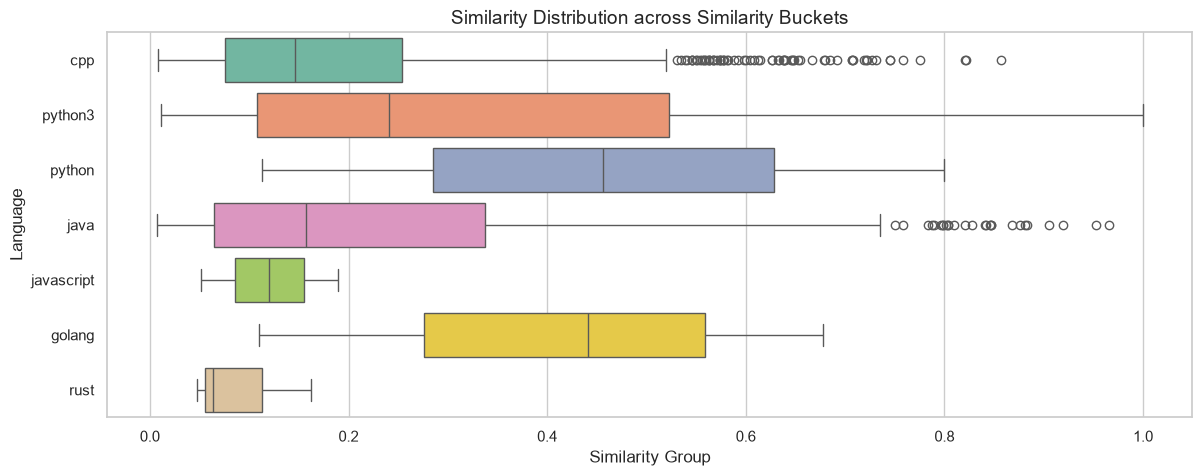

In [77]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df_remove_zero, x='similarity', y='language', palette='Set2')

plt.title('Similarity Distribution across Similarity Buckets', fontsize=14)
plt.xlabel('Similarity Group')
plt.ylabel('Language')
plt.show()
